# Pydantic

# laymen

Pydantic is a library that checks whether the data coming into your API is in the correct format and data type.

# Example

* User sends:

{
  "name": "Yash",
  "age": 22
}

* Pydantic Model:

class User(BaseModel):

    name: str

    age: int

✅ Valid data → Accepted



# Why Use Pydantic?
We use Pydantic to validate and check incoming data before it reaches our application.

* Validates data automatically
* Prevents wrong data from entering the app
* Reduces manual checking code
* Makes APIs safer and cleaner

# How Does Pydantic Work?

# Simple Flow

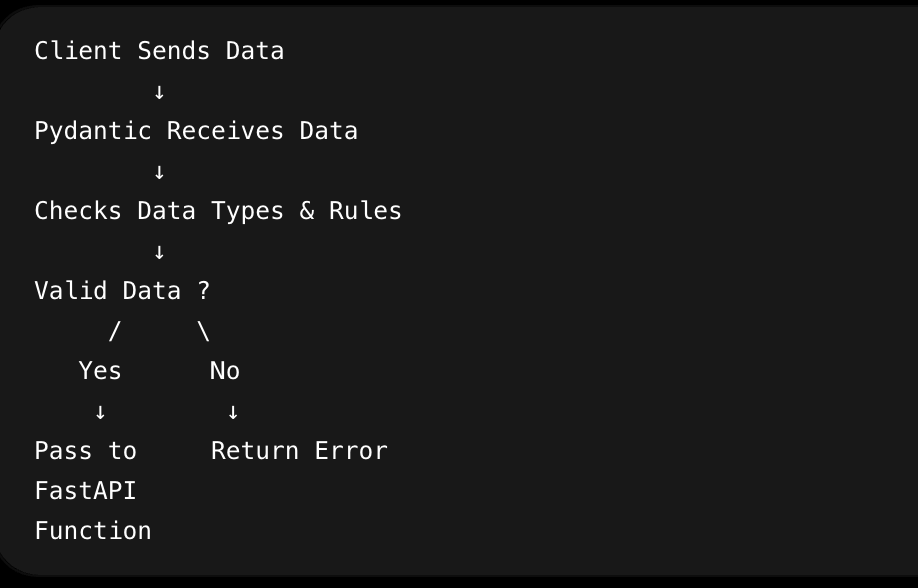

# Internally What Pydantic Does

When FastAPI sees:

user: User

it automatically:

* Reads JSON from request body.
* Creates a User object.
* Checks all fields.
* Validates data types.
* Returns errors if validation fails.
* Passes the validated object to your function.

# Example
Pydantic Model

from pydantic import BaseModel

class User(BaseModel):

    name: str

    age: int

FastAPI Endpoint

@app.post("/users")

def create_user(user: User):

    return user

# Case 1: Correct Data

User sends:

{
  "name": "Yash",
  "age": 22
}

What Happens?

Request
   ↓
Pydantic
   ↓
name = string ✓

age = integer ✓
   ↓
Pass to Function
   ↓
Response

# Result:

{
  "name": "Yash",
  "age": 22
}
# Case 2: Wrong Data

User sends:

{
  "name": "Yash",
  "age": "twenty two"
}

What Happens?

Request
   ↓
Pydantic
   ↓
name = string ✓

age = integer ✗
   ↓
Validation Error
   ↓
Function Never Runs

FastAPI returns an error automatically.

# Real-Life Analogy

Imagine an airport.

Passenger
    ↓
Security Check
    ↓
Valid Documents?
   /      \
 Yes       No
  ↓         ↓
Board      Stop

Flight

# In FastAPI:

Request Data
     ↓
Pydantic Check
     ↓
Valid?
  /      \
Yes       No
 ↓         ↓
Function   Error

* Pydantic = Security Check

# Pipe Validation

Pipe ek middleware jaisa component hota hai jo request data ko controller tak pahunchne se pehle:

Validate karta hai

Transform karta hai

Sanitize karta hai

# Why is it called a validation pipeline?

Because data goes through several steps:

Request
   ↓
Pydantic Schema Check
   ↓
Type Validation
   ↓
Constraint Validation
   ↓
Endpoint Function
   ↓
Response

# Field Validation

Field Validation ka matlab hai kisi field par rules lagana.

Jaise:

Name minimum 3 characters ho

Age 18 se zyada ho

Email valid format mein ho

# Code

In [1]:
from fastapi import FastAPI
from pydantic import BaseModel, Field

app = FastAPI()

class User(BaseModel):
    name: str = Field(min_length=3, max_length=20)
    age: int = Field(gt=18, lt=100)

@app.post("/users")
def create_user(user: User):
    return user

# What Do These Rules Mean?

name: str = Field(min_length=3, max_length=20)

Means:

Minimum Length = 3

Maximum Length = 20

# Examples:

"Ya"      ❌ Too short
"Yash"    ✅ Valid

age: int = Field(gt=18, lt=100)

Means:

gt = Greater Than

lt = Less Than

# Examples:

17   ❌ Invalid

22   ✅ Valid

120  ❌ Invalid

Email Validation

from pydantic import BaseModel, EmailStr

class User(BaseModel):

    email: EmailStr

Valid:

yash@gmail.com

Invalid:

yashgmail.com

# Metadata

"data about data"

Metadata = "data about data"

Yeh actual value nahi hoti, balki field ke baare mein extra information hoti hai.

name = "Yash"        ← Actual Data

description         ← Metadata

example             ← Metadata

min_length          ← Metadata/Validation Rule

max_length          ← Metadata/Validation Rule

# Why Attach Metadata?
* Better API Documentation

/docs mein description aur examples dikhte hain.
* Validation Rules

min_length, max_length, gt, lt etc.

* Clear Understanding

Dusre developers ko pata chal jata hai field ka purpose kya hai.

# Yes, in Pydantic we can attach metadata to fields using Field()

# Metadata includes descriptions, examples, default values, and validation constraints. It helps with validation and automatically improves API documentation in FastAPI.

# Code


In [2]:
from pydantic import BaseModel, Field

class User(BaseModel):
    name: str = Field(
        min_length=3,
        max_length=20,
        description="User's full name",
        example="Yash"
    )

/tmp/ipykernel_3954/1388851522.py:4: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'example'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  name: str = Field(


# Field Validator

Field Validator tab use karte hain jab simple rules (min_length, gt, lt) se kaam na chale aur hume custom validation likhni ho.

# How It Works

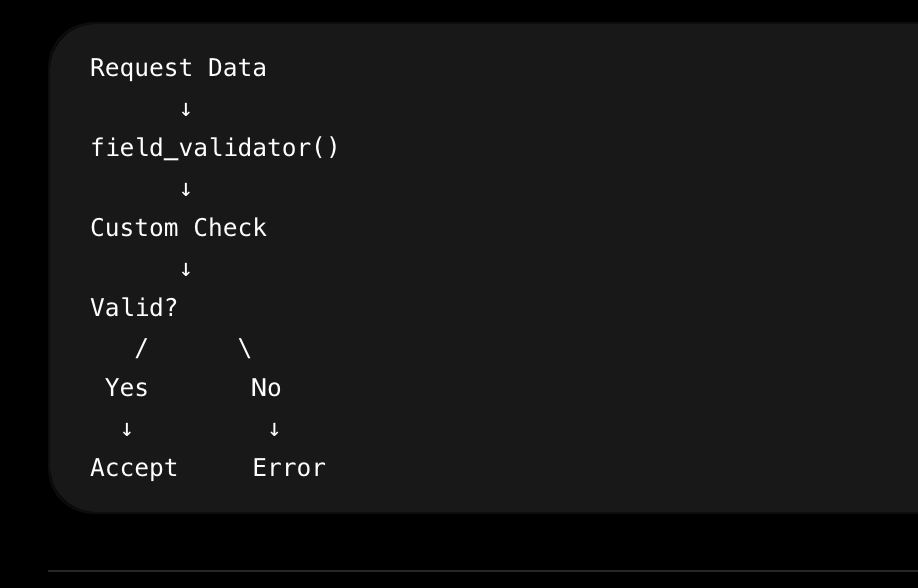

# Example

Maan lo name mein numbers allow nahi hain.

In [3]:
from pydantic import BaseModel, field_validator

class User(BaseModel):
    name: str

    @field_validator("name")
    @classmethod
    def validate_name(cls, value):
        if any(char.isdigit() for char in value):
            raise ValueError("Name cannot contain numbers")
        return value

Valid Input

{
  "name": "Yash"
}


✅ Accepted

Invalid Input

{
  "name": "Yash123"
}

❌ Error:

Name cannot contain numbers

# Field() vs Field Validator

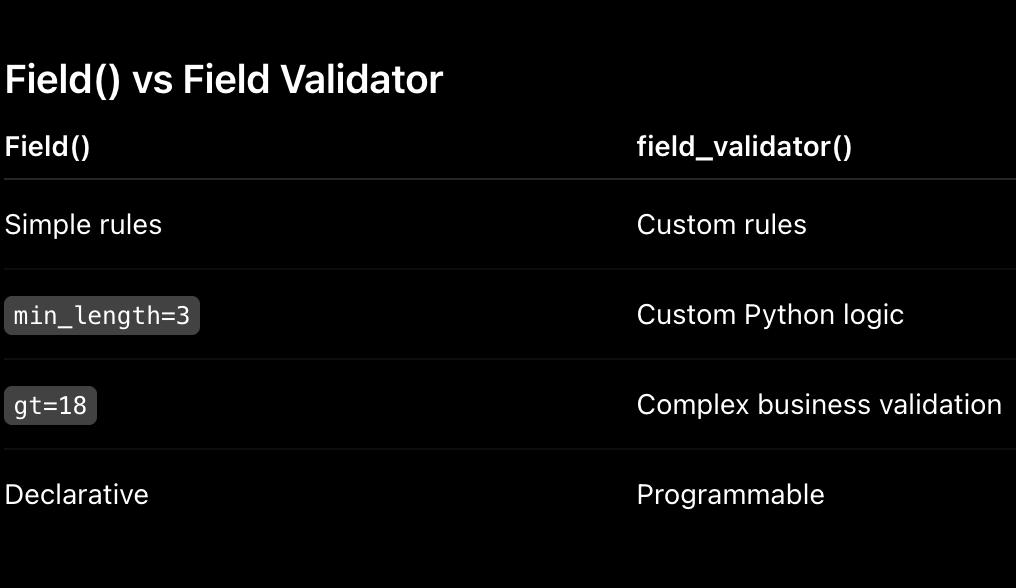

# Is code mein hum Pydantic ka ek model `User` define karte hain jisme `name` ek field hota hai. `@field_validator("name")` ka use karke hum ek custom validation rule lagate hain jo tab run hota hai jab bhi `name` field mein koi value aati hai. Is function ke andar hum check karte hain ki name ke andar koi number to nahi hai. Agar koi digit mil jata hai to hum `ValueError` raise kar dete hain aur message dete hain ki "Name cannot contain numbers", jisse data reject ho jata hai. Agar name bilkul sahi hota hai (sirf letters hote hain), to function value return kar deta hai aur data accept ho jata hai. Is tarah yeh validator ensure karta hai ki sirf valid name hi API tak pohche.



# Model Validator

Model Validator tab use hota hai jab hume ek hi field nahi, balki multiple fields ko saath mein validate karna ho.

# Example

Maan lo registration form mein:

Password
Confirm Password

# Rule:

Password aur Confirm Password same hone chahiye

Ye validation ek single field par nahi lag sakti, kyunki dono fields ko compare karna hai.

Isliye Model Validator use karte hain.

# Computed Fields


Computed Field ek aisi field hoti hai jo user input se nahi aati, balki dusri fields ko use karke automatically calculate hoti hai.

# Simple Example

Maan lo:

First Name = Yash
Last Name  = Raghubanshi

Hum chahte hain:

Full Name = Yash Raghubanshi

User full_name nahi bhej raha.

Ye automatically generate ho raha hai.

👉 Ye hi Computed Field hai.

# Nested Models

Nested Models ka matlab hai ek model ke andar dusra model use karna.

# Real-Life Example

Maan lo ek user hai aur uska address bhi store karna hai.

User Information
Name = Yash
Age = 22
Address Information
City = Varanasi
State = Uttar Pradesh

Address ko alag model bana sakte hain aur User model ke andar use kar sakte hain.

👉 Isse Nested Model kehte hain.

# Serialization

Serialization ka matlab hai Python object ko aise format mein convert karna jo easily send, store, ya share kiya ja sake (usually JSON).

# Simple Example

Python Object:

user = {
    "name": "Yash",
    "age": 22
}

Serialization ke baad:

{
  "name": "Yash",
  "age": 22
}

Ye JSON network par bheja ja sakta hai.



# Why Do We Need Serialization?

FastAPI internally Python objects use karta hai.

Lekin:

Browser
Mobile App
Frontend

Python objects nahi samajhte.

Wo JSON samajhte hain.

Isliye:

Python Object
      ↓
Serialization
      ↓
JSON
      ↓
Client

# FastAPI automatically:

User Object
      ↓
Serialization
      ↓
JSON Response


# Opposite: Deserialization
JSON
  ↓
Deserialization
  ↓
Python Object